# 🔢 Notebook 03 — Vectorización

Convertimos el texto limpio a números que el modelo puede procesar.
Comparamos **TF-IDF** vs **Bag of Words** y analizamos qué features
captura cada uno.

El modelo no ve palabras, ve números. Cómo transformemos el texto
define directamente qué puede aprender el modelo.
Un mal vectorizador hace imposible un buen modelo.

### ¿Por qué TF-IDF sobre BoW en este dataset?
- BoW cuenta apariciones brutas: 'the' pesa igual que 'thug'
- TF-IDF penaliza palabras frecuentes en todos los docs y premia
  las que discriminan entre clases
- Con mediana de 9 tokens por comentario, cada palabra cuenta

## 0. Imports y configuración

In [1]:
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import issparse
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'PROJECT_ROOT: {PROJECT_ROOT}')

/home/under/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT


In [2]:
# Carga de configuracion
CONFIG_FEAT = PROJECT_ROOT / 'configs' / 'features.yaml'
CONFIG_PIPE = PROJECT_ROOT / 'configs' / 'pipeline.yaml'

with open(CONFIG_FEAT) as f: feat_cfg = yaml.safe_load(f)
with open(CONFIG_PIPE) as f: pipe_cfg = yaml.safe_load(f)

vec_cfg    = feat_cfg['vectorization']
tfidf_cfg  = vec_cfg['tfidf']
bow_cfg    = vec_cfg['bow']
TARGET_BIN = pipe_cfg['data']['target_binary']
SUBLABELS  = pipe_cfg['data']['target_multilabel']
RAND_STATE = pipe_cfg['pipeline']['random_state']
TEST_SIZE  = pipe_cfg['pipeline']['test_size']

print('TF-IDF config:', tfidf_cfg)
print('BoW config    :', bow_cfg)
print(f'random_state  : {RAND_STATE} | test_size: {TEST_SIZE}')

TF-IDF config: {'max_features': 5000, 'ngram_range': [1, 2], 'sublinear_tf': True, 'min_df': 3}
BoW config    : {'max_features': 5000, 'ngram_range': [1, 1], 'min_df': 3}
random_state  : 42 | test_size: 0.2


## 1. Carga del texto preprocesado

Usamos el CSV generado por el notebook de preprocesamiento.
**Nunca** vectorizamos texto crudo.

In [3]:
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed' / 'v2' / 'comments_preprocessed.csv'

df = pd.read_csv(PROCESSED_PATH)
print(f'Dataset: {df.shape}')
print(f'Nulos en clean_text: {df["clean_text"].isnull().sum()}')
print(f'Vacios en clean_text: {(df["clean_text"] == "").sum()}')

# Rellenar vacios con placeholder para no romper el vectorizador
df['clean_text'] = df['clean_text'].fillna('').astype(str)

print(f'\nDistribucion target:')
print(df[TARGET_BIN].value_counts())
print()
print('Muestra texto limpio:')
for t in df['clean_text'].sample(4, random_state=42):
    print(f'  {repr(t[:80])}')

Dataset: (1000, 9)
Nulos en clean_text: 0
Vacios en clean_text: 0

Distribucion target:
IsToxic
False    538
True     462
Name: count, dtype: int64

Muestra texto limpio:
  'call anarchist defend cop shoot unarmed civilian highly disappointed beginning r'
  'mother tell I thing god bless woman'
  'love saem thing go peggy stupid ya kill ya self quick stlpd could ever wakeup'
  'next time line car start make burnout smoke riot gas non lethal eficient double '


## 2. Train / Test split

El split se hace **antes** de vectorizar para evitar data leakage.

> ⚠️ **Data leakage**: si vectorizas todo el dataset y luego splitteas,
> el vectorizador ha 'visto' el test set durante el fit. El vocabulario
> y los IDF scores estarán contaminados con datos de test.
> Resultado: métricas optimistas que no se replican en producción.

**Regla:** fit del vectorizador **solo** sobre X_train. Transform sobre ambos.

In [4]:
X = df['clean_text']
y_bin = df[TARGET_BIN]
y_multi = df[SUBLABELS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin,
    test_size=TEST_SIZE,
    random_state=RAND_STATE,
    stratify=y_bin          # misma proporcion toxic/no-toxic en train y test
)

print(f'Train : {len(X_train)} muestras')
print(f'Test  : {len(X_test)} muestras')
print()
print('Distribucion train:')
print(y_train.value_counts())
print()
print('Distribucion test:')
print(y_test.value_counts())

Train : 800 muestras
Test  : 200 muestras

Distribucion train:
IsToxic
False    430
True     370
Name: count, dtype: int64

Distribucion test:
IsToxic
False    108
True      92
Name: count, dtype: int64


## 3. TF-IDF — Term Frequency Inverse Document Frequency

### ¿Cómo funciona?
Para cada palabra en cada documento calcula:
```
TF-IDF(palabra, doc) = TF(palabra, doc) × IDF(palabra)

TF  = frecuencia de la palabra en este documento
IDF = log(total docs / docs que contienen la palabra)
```
**Resultado:** palabras raras pero relevantes tienen peso alto.
Palabras que aparecen en todos los docs (como 'said') tienen peso bajo.

### Por qué `sublinear_tf=True`
Sin esto, un comentario que dice 'kill' 10 veces pesa 10x más que uno que lo dice 1 vez.
Con `sublinear_tf`: `TF = 1 + log(count)` → escala logarítmica más razonable.

### Por qué `ngram_range=(1,2)`
Con solo unigramas: 'black' tiene el mismo peso en tóxico y no tóxico.
Con bigramas: 'black thug', 'black criminal' aparecen casi solo en tóxicos.

In [ ]:
# Fit SOLO sobre train — nunca sobre todo el dataset
tfidf = TfidfVectorizer(
    max_features = tfidf_cfg['max_features'],
    ngram_range  = tuple(tfidf_cfg['ngram_range']),
    sublinear_tf = tfidf_cfg['sublinear_tf'],
    min_df       = tfidf_cfg['min_df'],
    analyzer     = 'word',
    strip_accents= 'unicode',
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform sobre train
X_test_tfidf  = tfidf.transform(X_test)        # solo transform sobre test

print(f'Vocabulario TF-IDF : {len(tfidf.vocabulary_):,} features')
print(f'Shape X_train      : {X_train_tfidf.shape}')
print(f'Shape X_test       : {X_test_tfidf.shape}')
print(f'Tipo de matriz     : {type(X_train_tfidf).__name__} (sparse)')
print()

# Esparsidad: que % de valores son 0
total = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero = X_train_tfidf.nnz
sparsity = (1 - nonzero / total) * 100
print(f'Valores no-cero    : {nonzero:,} de {total:,}')
print(f'Esparsidad         : {sparsity:.1f}%')
print()
print('Ejemplo 5 features del vocabulario:')
vocab_sample = list(tfidf.vocabulary_.items())[:5]
for word, idx in vocab_sample:
    print(f'  "{word}" -> columna {idx}')

Vocabulario TF-IDF : 1,093 features
Shape X_train      : (800, 1093)
Shape X_test       : (200, 1093)
Tipo de matriz     : csr_matrix (sparse)

Valores no-cero    : 10,153 de 874,400
Esparsidad         : 98.8%

Ejemplo 5 features del vocabulario:
  "wonder" -> columna 1063
  "police" -> columna 706
  "expect" -> columna 300
  "happen" -> columna 410
  "abuse" -> columna 2


## 4. Análisis de features: ¿qué captura TF-IDF?

Identificamos las palabras y bigramas con mayor peso promedio
en comentarios tóxicos vs no tóxicos.
Esto nos dice si el vectorizador está capturando las señales correctas.

In [6]:
# Media de TF-IDF por feature para cada clase
# Usamos el indice del train set para separar por clase
y_train_arr = y_train.values
mask_toxic    = y_train_arr == True
mask_nontoxic = y_train_arr == False

# Media de cada feature en comentarios toxicos vs no toxicos
mean_toxic    = np.asarray(X_train_tfidf[mask_toxic].mean(axis=0)).flatten()
mean_nontoxic = np.asarray(X_train_tfidf[mask_nontoxic].mean(axis=0)).flatten()

feature_names = tfidf.get_feature_names_out()

feat_df = pd.DataFrame({
    'feature'   : feature_names,
    'toxic'     : mean_toxic,
    'nontoxic'  : mean_nontoxic,
    'diff'      : mean_toxic - mean_nontoxic
})

print('TOP 20 features mas discriminantes para TOXICO:')
print(feat_df.nlargest(20, 'diff')[['feature','toxic','nontoxic','diff']].to_string(index=False))
print()
print('TOP 20 features mas discriminantes para NO TOXICO:')
print(feat_df.nsmallest(20, 'diff')[['feature','toxic','nontoxic','diff']].to_string(index=False))

TOP 20 features mas discriminantes para TOXICO:
 feature    toxic  nontoxic     diff
     run 0.042957  0.004755 0.038203
    fuck 0.032995  0.002363 0.030632
   idiot 0.022649  0.000594 0.022055
    shit 0.021515  0.001077 0.020437
     ass 0.017153  0.000678 0.016475
   shoot 0.029243  0.013207 0.016035
   bitch 0.015237  0.000542 0.014695
  stupid 0.016636  0.002170 0.014466
    thug 0.014222  0.001859 0.012363
    dumb 0.011687  0.000672 0.011015
 fucking 0.012425  0.002065 0.010360
    cunt 0.010253  0.000000 0.010253
     get 0.036118  0.026375 0.009744
   white 0.024439  0.015152 0.009287
   black 0.033807  0.025079 0.008728
  racist 0.019295  0.010823 0.008472
    kill 0.016284  0.008030 0.008254
     cnn 0.014236  0.006024 0.008213
bullshit 0.008146  0.000000 0.008146
     job 0.012771  0.005113 0.007658

TOP 20 features mas discriminantes para NO TOXICO:
 feature    toxic  nontoxic      diff
   peggy 0.001108  0.017077 -0.015968
   thank 0.004179  0.020127 -0.015948
  stefan 

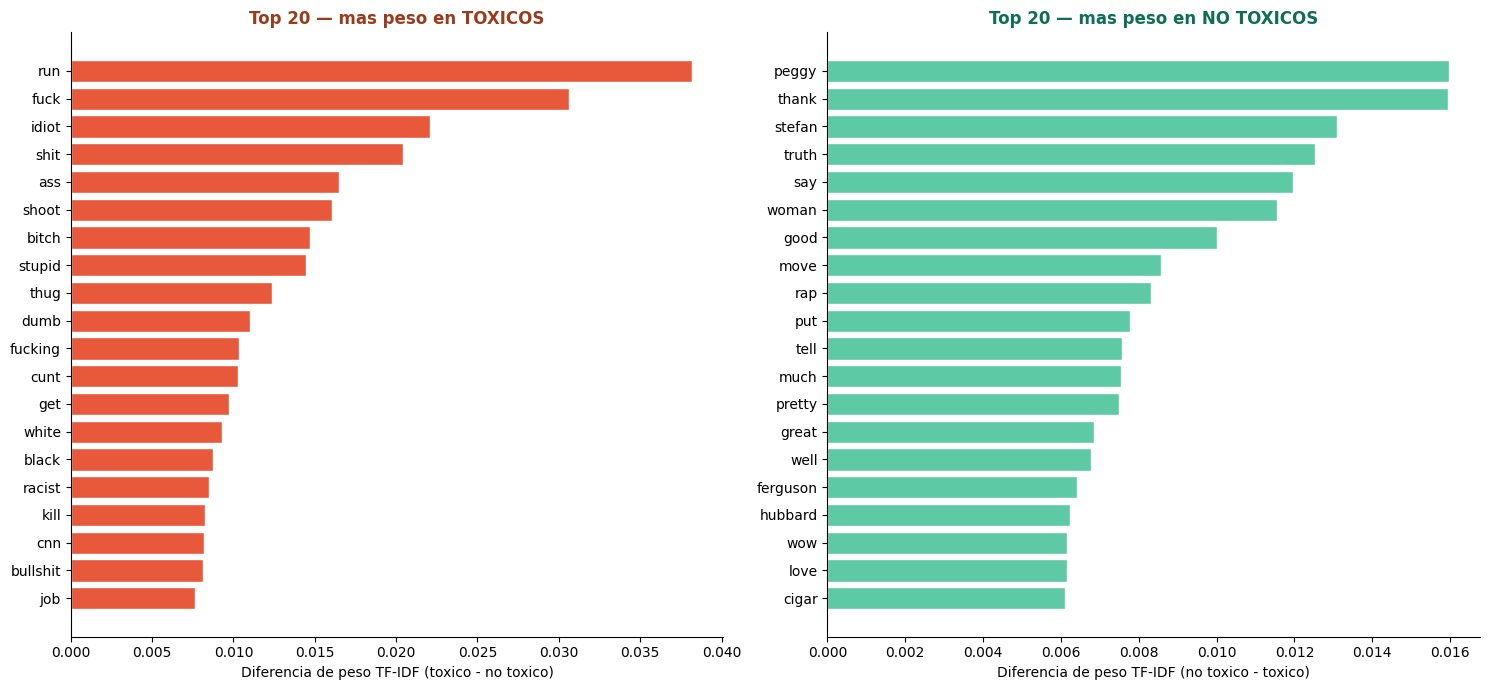

Guardado en reports/08_tfidf_top_features.png


In [7]:
# Visualizacion: top features por clase
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Top toxic
top_toxic = feat_df.nlargest(20, 'diff')
axes[0].barh(top_toxic['feature'], top_toxic['diff'], color='#E8593C', edgecolor='white')
axes[0].set_title('Top 20 — mas peso en TOXICOS', fontweight='bold', color='#993C1D')
axes[0].set_xlabel('Diferencia de peso TF-IDF (toxico - no toxico)')
axes[0].invert_yaxis()

# Top non-toxic
top_nontoxic = feat_df.nsmallest(20, 'diff')
axes[1].barh(top_nontoxic['feature'], top_nontoxic['diff'].abs(), color='#5DCAA5', edgecolor='white')
axes[1].set_title('Top 20 — mas peso en NO TOXICOS', fontweight='bold', color='#0F6E56')
axes[1].set_xlabel('Diferencia de peso TF-IDF (no toxico - toxico)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / '08_tfidf_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en reports/08_tfidf_top_features.png')

In [8]:
# Analisis de bigramas: los mas discriminantes
bigrams_df = feat_df[feat_df['feature'].str.contains(' ')]  # bigramas tienen espacio
unigrams_df = feat_df[~feat_df['feature'].str.contains(' ')]

print(f'Unigramas en vocabulario : {len(unigrams_df):,}')
print(f'Bigramas en vocabulario  : {len(bigrams_df):,}')
print()
print('TOP 15 bigramas toxicos:')
print(bigrams_df.nlargest(15, 'diff')[['feature','diff']].to_string(index=False))
print()
print('TOP 15 bigramas no toxicos:')
print(bigrams_df.nsmallest(15, 'diff')[['feature','diff']].to_string(index=False))

Unigramas en vocabulario : 902
Bigramas en vocabulario  : 191

TOP 15 bigramas toxicos:
        feature     diff
      get shoot 0.005373
     piece shit 0.005267
        get hit 0.003931
shoot apprehend 0.003739
        get way 0.003618
  rubber bullet 0.003527
law enforcement 0.003492
        go back 0.003289
       dumb ass 0.003264
      joe rogan 0.003253
       get kill 0.003235
        get job 0.003189
   black people 0.002936
  block traffic 0.002768
      kid would 0.002732

TOP 15 bigramas no toxicos:
         feature      diff
        mr brown -0.003869
    thank stefan -0.003827
      police car -0.003715
african american -0.003510
      people say -0.003140
  police officer -0.003081
 black community -0.002905
   peggy hubbard -0.002870
     pretty much -0.002829
       rap lyric -0.002804
 stefan molyneux -0.002705
       god bless -0.002689
      tell truth -0.002538
     black woman -0.002325
    deadly force -0.002221


## 5. Bag of Words — comparación

BoW simplemente cuenta cuántas veces aparece cada palabra.
Lo entrenamos con los mismos parámetros para comparar con TF-IDF.

**Diferencia clave:**
- BoW: comentario largo con 'stupid' 3 veces → peso 3
- TF-IDF: mismo comentario → peso log(3)×IDF('stupid')
- TF-IDF penaliza 'stupid' si aparece en muchos docs, BoW no.

In [9]:
bow = CountVectorizer(
    max_features = bow_cfg['max_features'],
    ngram_range  = tuple(bow_cfg['ngram_range']),
    min_df       = bow_cfg['min_df'],
    analyzer     = 'word',
    strip_accents= 'unicode',
)

X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print(f'Vocabulario BoW : {len(bow.vocabulary_):,} features')
print(f'Shape X_train   : {X_train_bow.shape}')
print(f'Shape X_test    : {X_test_bow.shape}')

Vocabulario BoW : 902 features
Shape X_train   : (800, 902)
Shape X_test    : (200, 902)


In [ ]:
# Comparativa de esparsidad y vocabulario
tfidf_sparse = (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])) * 100
bow_sparse   = (1 - X_train_bow.nnz / (X_train_bow.shape[0]*X_train_bow.shape[1])) * 100

print(f"{'':25} {'TF-IDF':>12} {'BoW':>12}")
print('-' * 52)
print(f"  {'Vocabulario':23} {len(tfidf.vocabulary_):>12,} {len(bow.vocabulary_):>12,}")
print(f"  {'Shape train':23} {str(X_train_tfidf.shape):>12} {str(X_train_bow.shape):>12}")
print(f"  {'Esparsidad':23} {tfidf_sparse:>11.1f}% {bow_sparse:>11.1f}%")
print(f"  {'Valores no-cero':23} {X_train_tfidf.nnz:>12,} {X_train_bow.nnz:>12,}")

                                TF-IDF          BoW
----------------------------------------------------
  Vocabulario                    1,093          902
  Shape train              (800, 1093)   (800, 902)
  Esparsidad                     98.8%        98.7%
  Valores no-cero               10,153        9,236

DECISION: TF-IDF es preferido en este dataset porque:
  - Penaliza palabras frecuentes en todos los docs
  - Premia palabras raras pero discriminantes (thug, bullcrap)
  - sublinear_tf evita que repeticion infle el peso
  - Con 9 tokens medios por doc, cada peso importa


## 6. Registro en MLflow

Registramos la configuración del vectorizador y las métricas de vocabulario.
En el siguiente notebook (baseline) compararemos si TF-IDF o BoW da mejor F1.

In [ ]:
MLFLOW_DIR = PROJECT_ROOT / 'mlruns'
mlflow.set_tracking_uri(f'file://{MLFLOW_DIR}')
mlflow.set_experiment('Youtube_project_data')

with mlflow.start_run(run_name='tfidf_vs_bow'):

    # Params del vectorizador
    mlflow.log_param('tfidf_max_features', tfidf_cfg['max_features'])
    mlflow.log_param('tfidf_ngram_range',  str(tuple(tfidf_cfg['ngram_range'])))
    mlflow.log_param('tfidf_sublinear_tf', tfidf_cfg['sublinear_tf'])
    mlflow.log_param('tfidf_min_df',       tfidf_cfg['min_df'])
    mlflow.log_param('bow_max_features',   bow_cfg['max_features'])
    mlflow.log_param('bow_ngram_range',    str(tuple(bow_cfg['ngram_range'])))
    mlflow.log_param('train_size',         len(X_train))
    mlflow.log_param('test_size',          len(X_test))
    mlflow.log_param('random_state',       RAND_STATE)

    # Metrics
    mlflow.log_metric('tfidf_vocab_size',   len(tfidf.vocabulary_))
    mlflow.log_metric('tfidf_sparsity_pct', round(tfidf_sparse, 2))
    mlflow.log_metric('bow_vocab_size',     len(bow.vocabulary_))
    mlflow.log_metric('bow_sparsity_pct',   round(bow_sparse, 2))
    mlflow.log_metric('n_bigrams_tfidf',    len(bigrams_df))
    mlflow.log_metric('n_unigrams_tfidf',   len(unigrams_df))

    # Artefactos
    mlflow.log_artifact(str(PROJECT_ROOT / 'reports' / 'v2' / '08_tfidf_top_features.png'))
    mlflow.log_artifact(str(CONFIG_FEAT))

    print(f'MLflow run registrado')
    print(f'  Run ID     : {mlflow.active_run().info.run_id}')
    print(f'  Experimento: Youtube_project_data')

MLflow run registrado
  Run ID     : f549c95a6e4c4a8dbbc9d5ae3d35c977
  Experimento: 03_vectorization


## 7. Conclusiones y decisiones

In [ ]:
print(f"""
CONCLUSIONES — VECTORIZACION
{'='*55}
Configuracion elegida:
  Metodo   : TF-IDF
  n-gramas : (1, 2) — unigramas + bigramas
  max_feat : {tfidf_cfg['max_features']:,}
  min_df   : {tfidf_cfg['min_df']} — filtra palabras en <{tfidf_cfg['min_df']} docs
  sublinear: True — escala logaritmica

Resultado:
  Vocabulario  : {len(tfidf.vocabulary_):,} features
  Shape train  : {X_train_tfidf.shape}
  Shape test   : {X_test_tfidf.shape}
  Esparsidad   : {tfidf_sparse:.1f}%

Por que TF-IDF > BoW en este dataset:
  - 'black' aparece en ambas clases -> BoW no discrimina
  - TF-IDF baja el peso de palabras ubicuas
  - Bigramas capturan 'black thug', 'kill cop' como una unidad
  - Con 9 tokens medios por doc, el IDF marca diferencias claras

Objetos disponibles para el siguiente notebook:
  X_train_tfidf -> matriz sparse train
  X_test_tfidf  -> matriz sparse test
  y_train       -> labels train
  y_test        -> labels test
  tfidf         -> vectorizador entrenado
""")


CONCLUSIONES — VECTORIZACION
Configuracion elegida:
  Metodo   : TF-IDF
  n-gramas : (1, 2) — unigramas + bigramas
  max_feat : 5,000
  min_df   : 3 — filtra palabras en <3 docs
  sublinear: True — escala logaritmica

Resultado:
  Vocabulario  : 1,093 features
  Shape train  : (800, 1093)
  Shape test   : (200, 1093)
  Esparsidad   : 98.8%

Por que TF-IDF > BoW en este dataset:
  - 'black' aparece en ambas clases -> BoW no discrimina
  - TF-IDF baja el peso de palabras ubicuas
  - Bigramas capturan 'black thug', 'kill cop' como una unidad
  - Con 9 tokens medios por doc, el IDF marca diferencias claras

Objetos disponibles para el siguiente notebook:
  X_train_tfidf -> matriz sparse train
  X_test_tfidf  -> matriz sparse test
  y_train       -> labels train
  y_test        -> labels test
  tfidf         -> vectorizador entrenado

Siguiente: 04_baseline.ipynb
  Logistic Regression + StratifiedKFold + MLflow

